In [1]:
%cd ..

/home/bhchen/LearnKalmanGain


In [2]:
import torch
import matplotlib.pyplot as plt
import os
import pandas as pd

[Saved] PDF: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_sigma1.0/cov_diff_absolute_sigma_1.0.pdf
[Saved] PDF: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_sigma1.0/rrmse_absolute_sigma_1.0.pdf
[Saved] PDF: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_sigma1.0/time_absolute_sigma_1.0.pdf
[Saved] PDF: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_sigma1.0/cov_diff_improvement_sigma_1.0.pdf
[Saved] PDF: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_sigma1.0/rrmse_improvement_sigma_1.0.pdf
[Saved] PDF: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_sigma1.0/time_improvement_sigma_1.0.pdf
[Saved] PDF: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_sigma1.0/shared_legend_sigma_1.0.pdf

Processing complete.


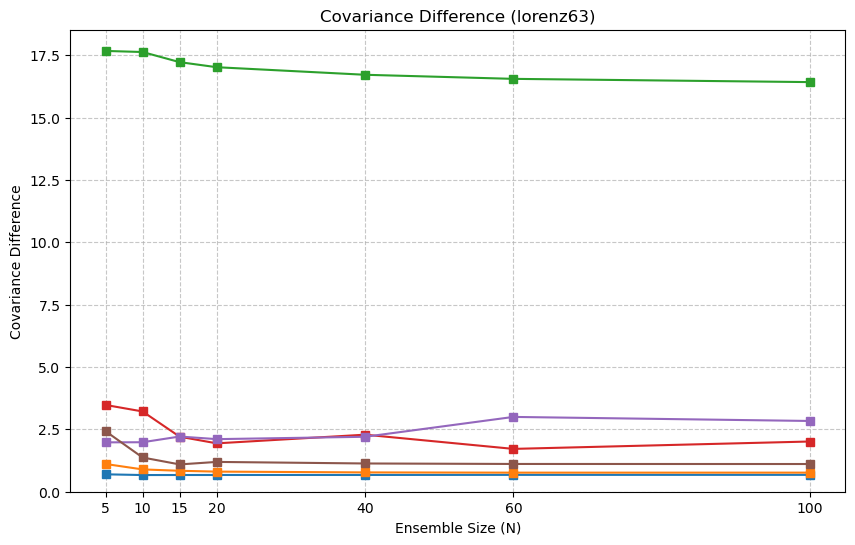

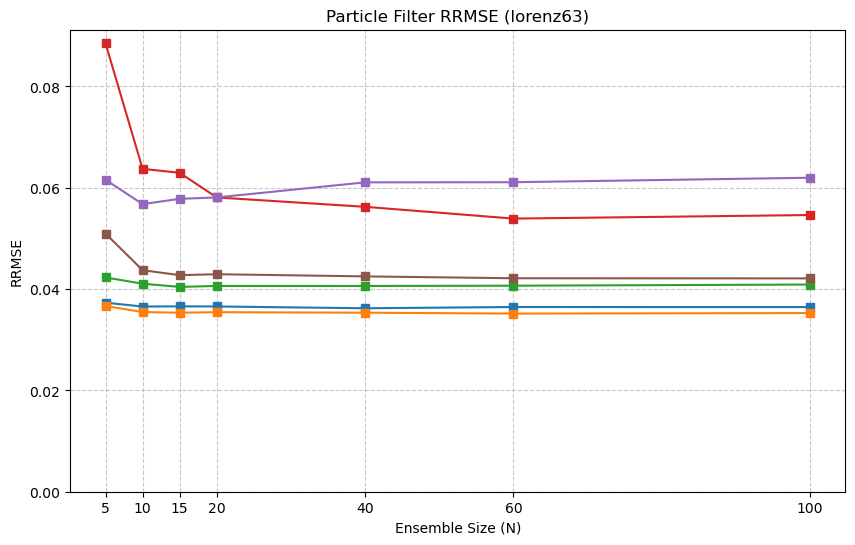

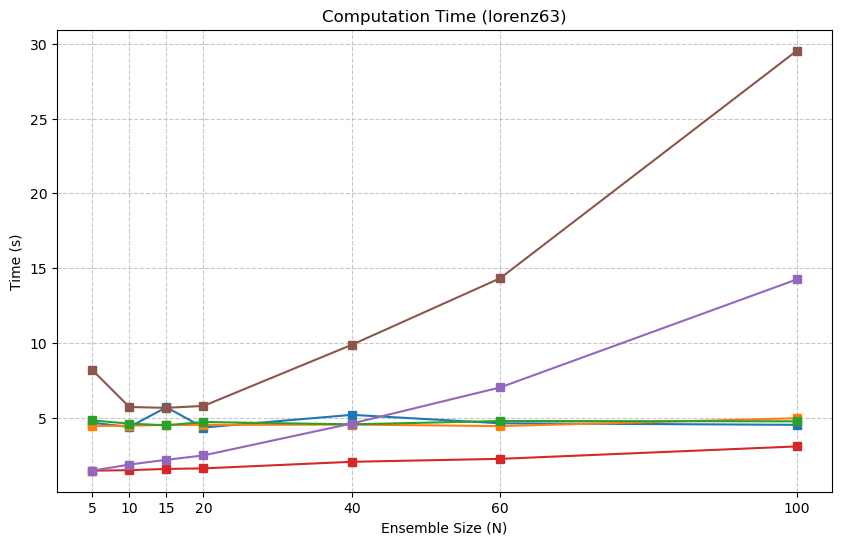

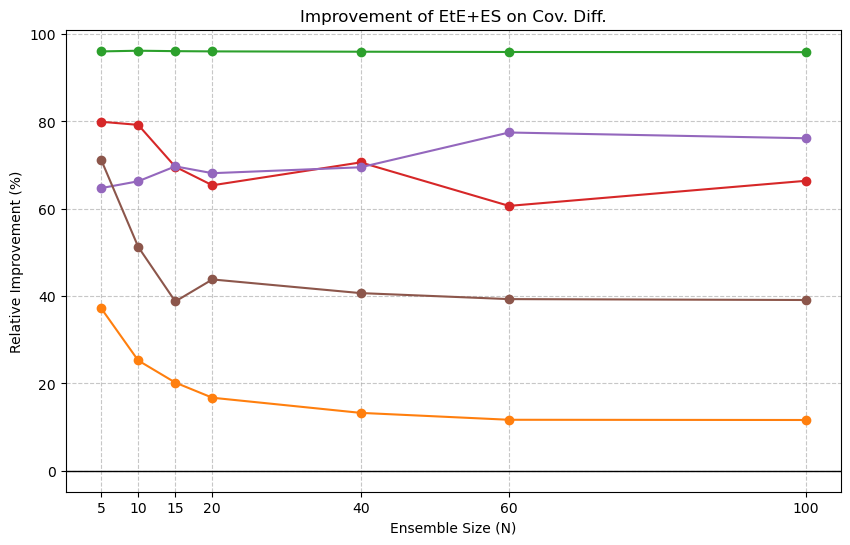

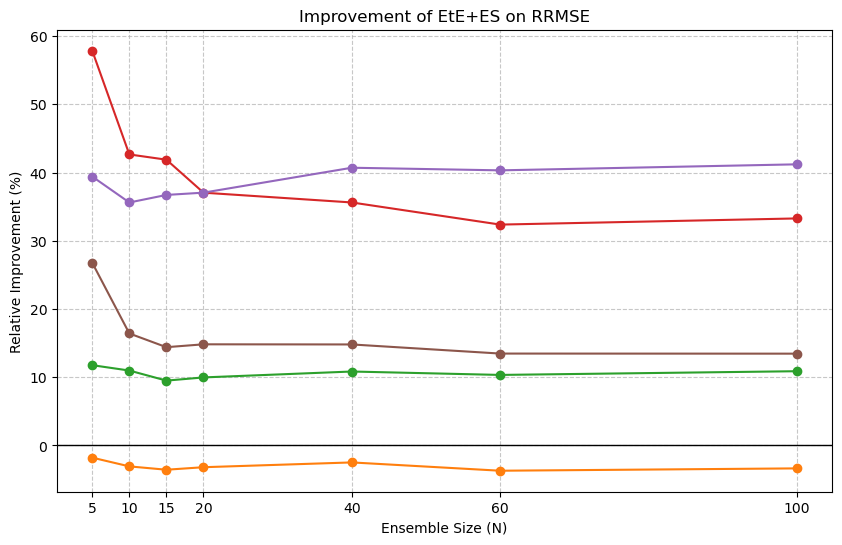

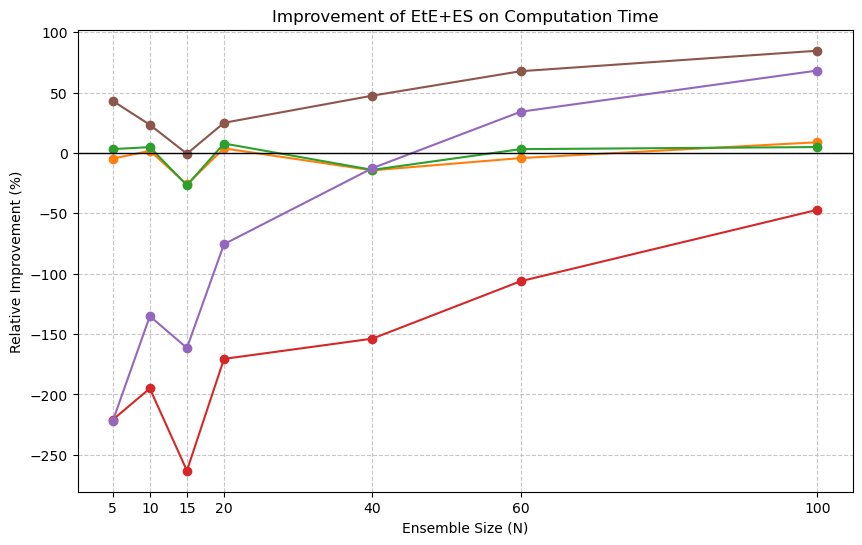

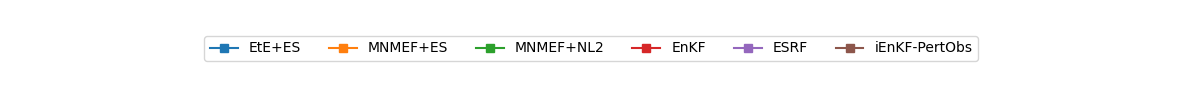

In [3]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

# --- [CONFIGURATION & SETUP] ---
DATASET = "lorenz63"
SIGMA_Y = 1.0  
SAVE_DIR = os.path.join("save", "figures", f"{DATASET}_sigma{SIGMA_Y}")
os.makedirs(SAVE_DIR, exist_ok=True)

# Global flag to control legend visibility in individual plots
INCLUDE_LEGEND_IN_PLOTS = False

ensemble_sizes = [5, 10, 15, 20, 40, 60, 100]

data_folders = [
    "lorenz63_EtE_LRes/2025-12-25_15-10lorenz63_1.0_10_60_8192_es_joint_EtE-LRes",
    "lorenz63_EtE_LRes/2026-01-14_01-06lorenz63_1.0_10_60_8192_es_joint_CorrTerms",
    "lorenz63_EtE_LRes/2026-01-07_17-33lorenz63_1.0_10_60_8192_nl2_joint_CorrTerms",
    "lorenz63_benchmarks/benchmark_lorenz63_1.0_EnKF",
    "lorenz63_benchmarks/benchmark_lorenz63_1.0_ESRF",
    "lorenz63_benchmarks/benchmark_lorenz63_1.0_iEnKS-PertObs",
]

method_names = [
    'EtE+ES', 
    'MNMEF+ES',
    'MNMEF+NL2',
    "EnKF",
    "ESRF",
    "iEnKF-PertObs",
]

TARGET_METHOD = 'EtE+ES' 

# --- [COLOR MAPPING SETUP] ---
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
METHOD_COLORS = {name: colors[i % len(colors)] for i, name in enumerate(method_names)}

# --- [DATA LOADING] ---
results = {}

for i, folder in enumerate(data_folders):
    for ens_size in ensemble_sizes:
        filename = f"output_records_{ens_size}.pt"
        method_name = method_names[i]
        data_file = os.path.join("save", folder, filename)

        try:
            data = torch.load(data_file, weights_only=True)
            
            # Extract metrics
            cov_diff = data["nn"]['cov_diff']
            pf_rmse = data["nn"]['pf_rmse']
            t = data["time"]
            rrmse = data["nn"].get('pf_rrmse', float('nan'))
            rcov_diff = data["nn"].get('rcov_diff', float('nan'))

            results.setdefault(method_name, {})
            for key in ['cov_diff', 'pf_rmse', 'rrmse', 'rcov_diff', 'time']:
                results[method_name].setdefault(key, [])

            results[method_name]['cov_diff'].append(cov_diff)
            results[method_name]['pf_rmse'].append(pf_rmse)
            results[method_name]['rrmse'].append(rrmse)
            results[method_name]['rcov_diff'].append(rcov_diff)
            results[method_name]['time'].append(t)
            
        except FileNotFoundError:
            print(f"Warning: File {data_file} not found.")

# --- [HELPER FUNCTIONS] ---
def save_figure_and_log(fig, filename):
    """
    Saves figure to disk in PDF/PNG.
    Input: fig object, filename string
    Output: None
    """
    path_pdf = os.path.join(SAVE_DIR, f"{filename}.pdf")
    path_png = os.path.join(SAVE_DIR, f"{filename}.png")
    
    fig.savefig(path_pdf, bbox_inches='tight', format='pdf')
    fig.savefig(path_png, bbox_inches='tight', format='png', dpi=300)
    print(f"[Saved] PDF: {os.path.abspath(path_pdf)}")

def calculate_relative_improvement(metric_key):
    """
    Computes improvement of TARGET_METHOD over others.
    Input: metric_key string
    Output: dict {method: improvement_array}
    """
    if TARGET_METHOD not in results:
        print(f"Target method {TARGET_METHOD} not found.")
        return {}

    psef_vals = np.array(results[TARGET_METHOD][metric_key])
    imp_data = {}

    for method in results.keys():
        if method == TARGET_METHOD: continue 
        bench_vals = np.array(results[method][metric_key])
        improvement = (bench_vals - psef_vals) / bench_vals * 100
        imp_data[method] = improvement
    
    return imp_data

def add_legend_if_required(ax):
    """
    Adds legend to the right side if global flag is set.
    Input: ax object
    Output: None
    """
    if INCLUDE_LEGEND_IN_PLOTS:
        # Place legend outside to the right
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# --- [PLOTTING ABSOLUTE METRICS] ---

# 1. Covariance Difference
fig1, ax1 = plt.subplots(figsize=(10, 6))
for key in results.keys():
    ax1.plot(ensemble_sizes, results[key]['cov_diff'], marker='s', label=key, color=METHOD_COLORS[key])
ax1.set_title(f'Covariance Difference ({DATASET})')
ax1.set_xlabel('Ensemble Size (N)')
ax1.set_ylabel('Covariance Difference')
ax1.set_xticks(ensemble_sizes)
ax1.set_ylim(bottom=0)
ax1.grid(True, linestyle='--', alpha=0.7)
add_legend_if_required(ax1)
save_figure_and_log(fig1, f"cov_diff_absolute_sigma_{SIGMA_Y}")

# 2. Particle Filter RRMSE
fig2, ax4 = plt.subplots(figsize=(10, 6))
for key in results.keys():
    ax4.plot(ensemble_sizes, results[key]['rrmse'], marker='s', label=key, color=METHOD_COLORS[key])
ax4.set_title(f'Particle Filter RRMSE ({DATASET})')
ax4.set_xlabel('Ensemble Size (N)')
ax4.set_ylabel('RRMSE')
ax4.set_xticks(ensemble_sizes)
ax4.set_ylim(bottom=0)
ax4.grid(True, linestyle='--', alpha=0.7)
add_legend_if_required(ax4)
save_figure_and_log(fig2, f"rrmse_absolute_sigma_{SIGMA_Y}")

# 3. Time
fig5, ax5 = plt.subplots(figsize=(10, 6))
for key in results.keys():
    ax5.plot(ensemble_sizes, results[key]['time'], marker='s', label=key, color=METHOD_COLORS[key])
ax5.set_title(f'Computation Time ({DATASET})')
ax5.set_xlabel('Ensemble Size (N)')
ax5.set_ylabel('Time (s)')
ax5.set_xticks(ensemble_sizes)
ax5.grid(True, linestyle='--', alpha=0.7)
add_legend_if_required(ax5)
save_figure_and_log(fig5, f"time_absolute_sigma_{SIGMA_Y}")

# --- [PLOTTING RELATIVE IMPROVEMENT] ---

# 1. Relative Improvement: Covariance Difference
imp_cov = calculate_relative_improvement('cov_diff')
if imp_cov:
    fig_imp1, ax_imp1 = plt.subplots(figsize=(10, 6))
    for key, val in imp_cov.items():
        ax_imp1.plot(ensemble_sizes, val, marker='o', label=f"{key}", color=METHOD_COLORS[key])
    ax_imp1.set_title(f'Improvement of {TARGET_METHOD} on Cov. Diff.')
    ax_imp1.set_xlabel('Ensemble Size (N)')
    ax_imp1.set_ylabel('Relative Improvement (%)')
    ax_imp1.set_xticks(ensemble_sizes)
    ax_imp1.grid(True, linestyle='--', alpha=0.7)
    ax_imp1.axhline(0, color='black', linewidth=1, linestyle='-')
    add_legend_if_required(ax_imp1)
    save_figure_and_log(fig_imp1, f"cov_diff_improvement_sigma_{SIGMA_Y}")

# 2. Relative Improvement: RRMSE
imp_rrmse = calculate_relative_improvement('rrmse')
if imp_rrmse:
    fig_imp2, ax_imp2 = plt.subplots(figsize=(10, 6))
    for key, val in imp_rrmse.items():
        ax_imp2.plot(ensemble_sizes, val, marker='o', label=f"{key}", color=METHOD_COLORS[key])
    ax_imp2.set_title(f'Improvement of {TARGET_METHOD} on RRMSE')
    ax_imp2.set_xlabel('Ensemble Size (N)')
    ax_imp2.set_ylabel('Relative Improvement (%)')
    ax_imp2.set_xticks(ensemble_sizes)
    ax_imp2.grid(True, linestyle='--', alpha=0.7)
    ax_imp2.axhline(0, color='black', linewidth=1, linestyle='-')
    add_legend_if_required(ax_imp2)
    save_figure_and_log(fig_imp2, f"rrmse_improvement_sigma_{SIGMA_Y}")

# 3. Relative Improvement: Time
imp_time = calculate_relative_improvement('time')
if imp_time:
    fig_imp3, ax_imp3 = plt.subplots(figsize=(10, 6))
    for key, val in imp_time.items():
        ax_imp3.plot(ensemble_sizes, val, marker='o', label=f"{key}", color=METHOD_COLORS[key])
    ax_imp3.set_title(f'Improvement of {TARGET_METHOD} on Computation Time')
    ax_imp3.set_xlabel('Ensemble Size (N)')
    ax_imp3.set_ylabel('Relative Improvement (%)')
    ax_imp3.set_xticks(ensemble_sizes)
    ax_imp3.grid(True, linestyle='--', alpha=0.7)
    ax_imp3.axhline(0, color='black', linewidth=1, linestyle='-')
    add_legend_if_required(ax_imp3)
    save_figure_and_log(fig_imp3, f"time_improvement_sigma_{SIGMA_Y}")

# --- [SEPARATE LEGEND GENERATION] ---
# Keep standalone legend as backup
handles, labels = ax1.get_legend_handles_labels()
fig_leg = plt.figure(figsize=(len(labels) * 2.5, 1.0))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')
ax_leg.legend(handles, labels, loc='center', ncol=len(labels), frameon=True)
save_figure_and_log(fig_leg, f"shared_legend_sigma_{SIGMA_Y}")

print("\nProcessing complete.")

[Saved] PDF: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_sigma0.7/cov_diff_absolute_sigma_0.7.pdf
[Saved] PDF: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_sigma0.7/rrmse_absolute_sigma_0.7.pdf
[Saved] PDF: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_sigma0.7/time_absolute_sigma_0.7.pdf
[Saved] PDF: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_sigma0.7/cov_diff_improvement_sigma_0.7.pdf
[Saved] PDF: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_sigma0.7/rrmse_improvement_sigma_0.7.pdf
[Saved] PDF: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_sigma0.7/time_improvement_sigma_0.7.pdf
[Saved] PDF: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_sigma0.7/shared_legend_sigma_0.7.pdf

Processing complete.


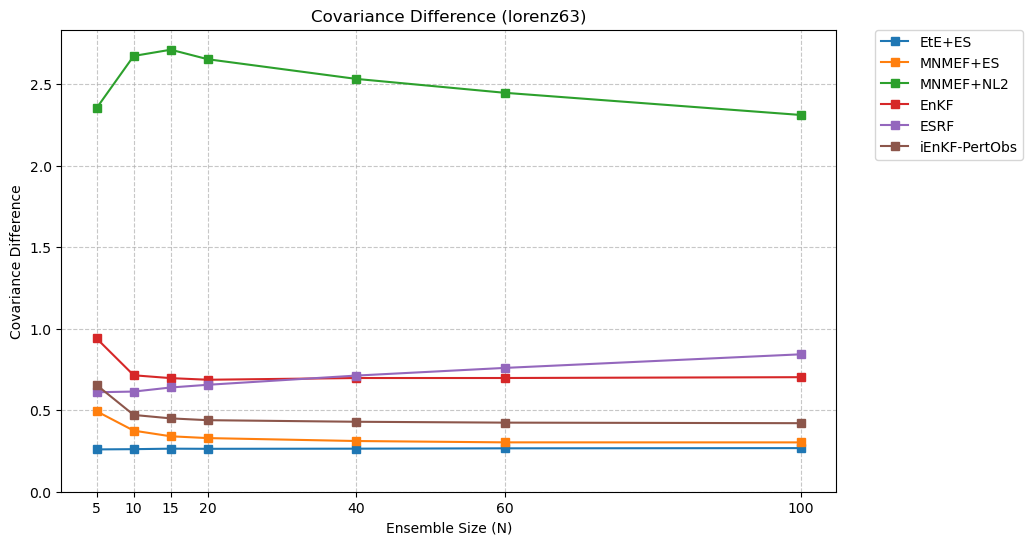

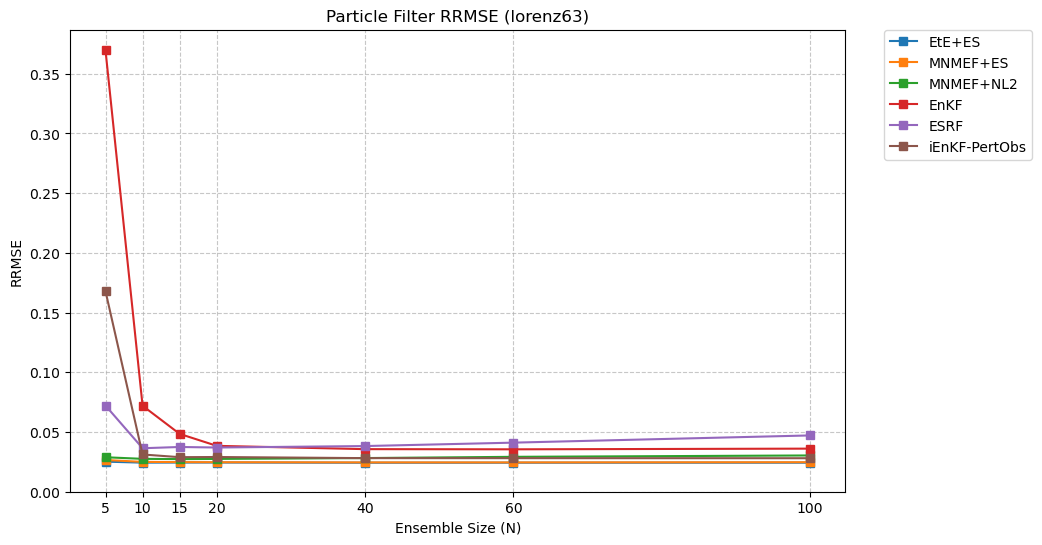

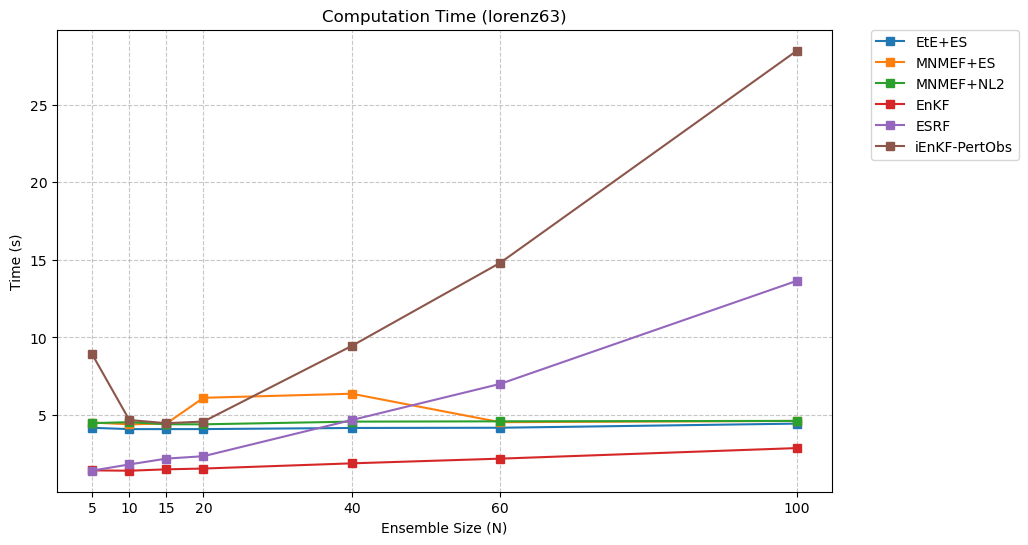

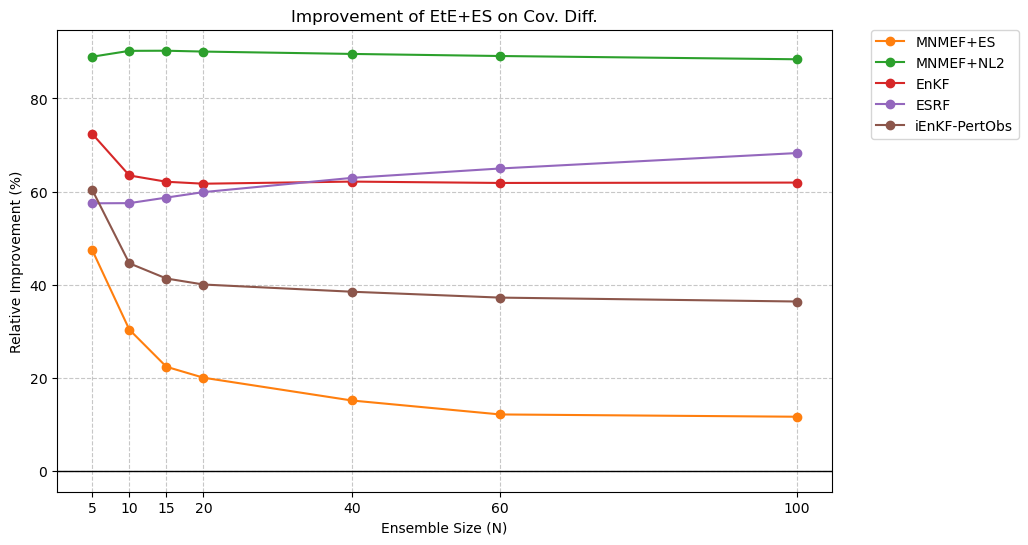

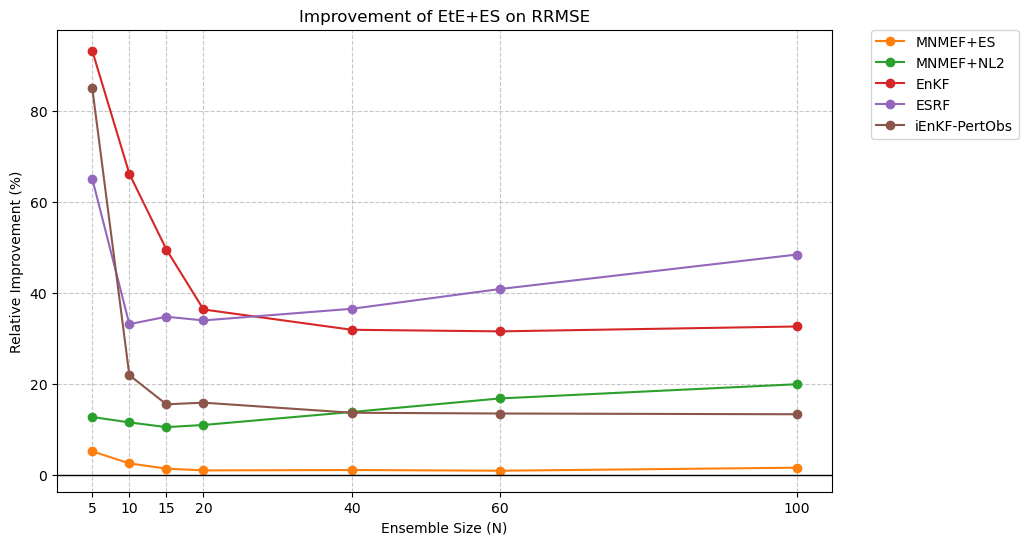

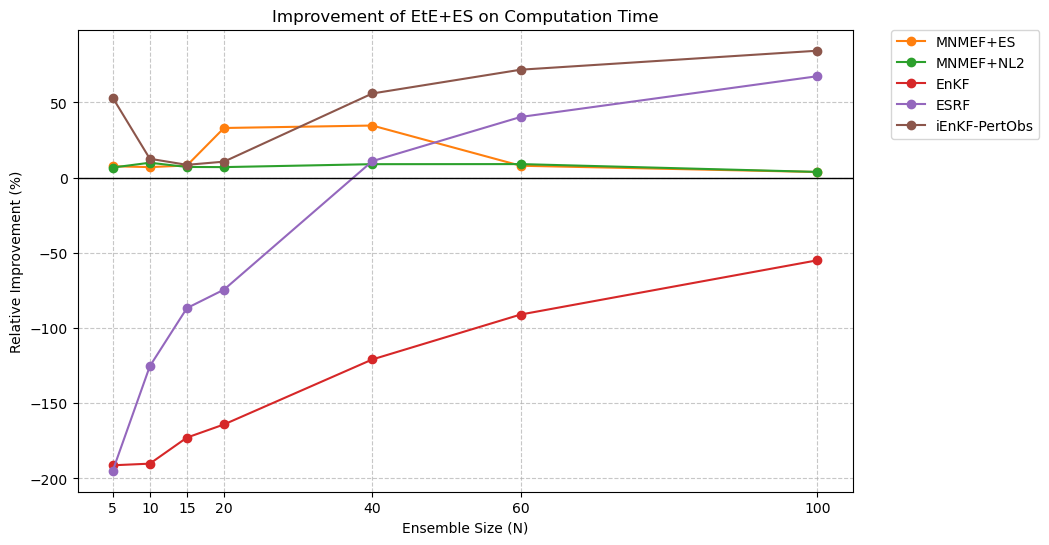

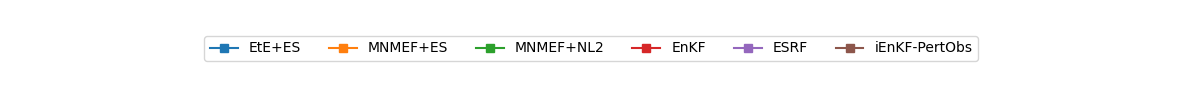

In [8]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

# --- [CONFIGURATION & SETUP] ---
DATASET = "lorenz63"
SIGMA_Y = 0.7  
SAVE_DIR = os.path.join("save", "figures", f"{DATASET}_sigma{SIGMA_Y}")
os.makedirs(SAVE_DIR, exist_ok=True)

# Global flag to control legend visibility in individual plots
INCLUDE_LEGEND_IN_PLOTS = True 

ensemble_sizes = [5, 10, 15, 20, 40, 60, 100]

data_folders = [
    "lorenz63_EtE_LRes/2026-01-14_17-49lorenz63_0.7_10_60_8192_es_joint_EtE-LRes",
    "lorenz63_EtE_LRes/2026-01-14_18-04lorenz63_0.7_10_60_8192_es_joint_CorrTerms",
    "lorenz63_EtE_LRes/2026-01-14_18-04lorenz63_0.7_10_60_8192_nl2_joint_CorrTerms",
    "lorenz63_benchmarks/benchmark_lorenz63_0.7_EnKF",
    "lorenz63_benchmarks/benchmark_lorenz63_0.7_ESRF",
    "lorenz63_benchmarks/benchmark_lorenz63_0.7_iEnKS-PertObs",
]

method_names = [
    'EtE+ES', 
    'MNMEF+ES',
    'MNMEF+NL2',
    "EnKF",
    "ESRF",
    "iEnKF-PertObs",
]

TARGET_METHOD = 'EtE+ES' 

# --- [COLOR MAPPING SETUP] ---
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
METHOD_COLORS = {name: colors[i % len(colors)] for i, name in enumerate(method_names)}

# --- [DATA LOADING] ---
results = {}

for i, folder in enumerate(data_folders):
    for ens_size in ensemble_sizes:
        filename = f"output_records_{ens_size}.pt"
        method_name = method_names[i]
        data_file = os.path.join("save", folder, filename)

        try:
            data = torch.load(data_file, weights_only=True)
            
            # Extract metrics
            cov_diff = data["nn"]['cov_diff']
            pf_rmse = data["nn"]['pf_rmse']
            t = data["time"]
            rrmse = data["nn"].get('pf_rrmse', float('nan'))
            rcov_diff = data["nn"].get('rcov_diff', float('nan'))

            results.setdefault(method_name, {})
            for key in ['cov_diff', 'pf_rmse', 'rrmse', 'rcov_diff', 'time']:
                results[method_name].setdefault(key, [])

            results[method_name]['cov_diff'].append(cov_diff)
            results[method_name]['pf_rmse'].append(pf_rmse)
            results[method_name]['rrmse'].append(rrmse)
            results[method_name]['rcov_diff'].append(rcov_diff)
            results[method_name]['time'].append(t)
            
        except FileNotFoundError:
            print(f"Warning: File {data_file} not found.")

# --- [HELPER FUNCTIONS] ---
def save_figure_and_log(fig, filename):
    """
    Saves figure to disk in PDF/PNG.
    Input: fig object, filename string
    Output: None
    """
    path_pdf = os.path.join(SAVE_DIR, f"{filename}.pdf")
    path_png = os.path.join(SAVE_DIR, f"{filename}.png")
    
    fig.savefig(path_pdf, bbox_inches='tight', format='pdf')
    fig.savefig(path_png, bbox_inches='tight', format='png', dpi=300)
    print(f"[Saved] PDF: {os.path.abspath(path_pdf)}")

def calculate_relative_improvement(metric_key):
    """
    Computes improvement of TARGET_METHOD over others.
    Input: metric_key string
    Output: dict {method: improvement_array}
    """
    if TARGET_METHOD not in results:
        print(f"Target method {TARGET_METHOD} not found.")
        return {}

    psef_vals = np.array(results[TARGET_METHOD][metric_key])
    imp_data = {}

    for method in results.keys():
        if method == TARGET_METHOD: continue 
        bench_vals = np.array(results[method][metric_key])
        improvement = (bench_vals - psef_vals) / bench_vals * 100
        imp_data[method] = improvement
    
    return imp_data

def add_legend_if_required(ax):
    """
    Adds legend to the right side if global flag is set.
    Input: ax object
    Output: None
    """
    if INCLUDE_LEGEND_IN_PLOTS:
        # Place legend outside to the right
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# --- [PLOTTING ABSOLUTE METRICS] ---

# 1. Covariance Difference
fig1, ax1 = plt.subplots(figsize=(10, 6))
for key in results.keys():
    ax1.plot(ensemble_sizes, results[key]['cov_diff'], marker='s', label=key, color=METHOD_COLORS[key])
ax1.set_title(f'Covariance Difference ({DATASET})')
ax1.set_xlabel('Ensemble Size (N)')
ax1.set_ylabel('Covariance Difference')
ax1.set_xticks(ensemble_sizes)
ax1.set_ylim(bottom=0)
ax1.grid(True, linestyle='--', alpha=0.7)
add_legend_if_required(ax1)
save_figure_and_log(fig1, f"cov_diff_absolute_sigma_{SIGMA_Y}")

# 2. Particle Filter RRMSE
fig2, ax4 = plt.subplots(figsize=(10, 6))
for key in results.keys():
    ax4.plot(ensemble_sizes, results[key]['rrmse'], marker='s', label=key, color=METHOD_COLORS[key])
ax4.set_title(f'Particle Filter RRMSE ({DATASET})')
ax4.set_xlabel('Ensemble Size (N)')
ax4.set_ylabel('RRMSE')
ax4.set_xticks(ensemble_sizes)
ax4.set_ylim(bottom=0)
ax4.grid(True, linestyle='--', alpha=0.7)
add_legend_if_required(ax4)
save_figure_and_log(fig2, f"rrmse_absolute_sigma_{SIGMA_Y}")

# 3. Time
fig5, ax5 = plt.subplots(figsize=(10, 6))
for key in results.keys():
    ax5.plot(ensemble_sizes, results[key]['time'], marker='s', label=key, color=METHOD_COLORS[key])
ax5.set_title(f'Computation Time ({DATASET})')
ax5.set_xlabel('Ensemble Size (N)')
ax5.set_ylabel('Time (s)')
ax5.set_xticks(ensemble_sizes)
ax5.grid(True, linestyle='--', alpha=0.7)
add_legend_if_required(ax5)
save_figure_and_log(fig5, f"time_absolute_sigma_{SIGMA_Y}")

# --- [PLOTTING RELATIVE IMPROVEMENT] ---

# 1. Relative Improvement: Covariance Difference
imp_cov = calculate_relative_improvement('cov_diff')
if imp_cov:
    fig_imp1, ax_imp1 = plt.subplots(figsize=(10, 6))
    for key, val in imp_cov.items():
        ax_imp1.plot(ensemble_sizes, val, marker='o', label=f"{key}", color=METHOD_COLORS[key])
    ax_imp1.set_title(f'Improvement of {TARGET_METHOD} on Cov. Diff.')
    ax_imp1.set_xlabel('Ensemble Size (N)')
    ax_imp1.set_ylabel('Relative Improvement (%)')
    ax_imp1.set_xticks(ensemble_sizes)
    ax_imp1.grid(True, linestyle='--', alpha=0.7)
    ax_imp1.axhline(0, color='black', linewidth=1, linestyle='-')
    add_legend_if_required(ax_imp1)
    save_figure_and_log(fig_imp1, f"cov_diff_improvement_sigma_{SIGMA_Y}")

# 2. Relative Improvement: RRMSE
imp_rrmse = calculate_relative_improvement('rrmse')
if imp_rrmse:
    fig_imp2, ax_imp2 = plt.subplots(figsize=(10, 6))
    for key, val in imp_rrmse.items():
        ax_imp2.plot(ensemble_sizes, val, marker='o', label=f"{key}", color=METHOD_COLORS[key])
    ax_imp2.set_title(f'Improvement of {TARGET_METHOD} on RRMSE')
    ax_imp2.set_xlabel('Ensemble Size (N)')
    ax_imp2.set_ylabel('Relative Improvement (%)')
    ax_imp2.set_xticks(ensemble_sizes)
    ax_imp2.grid(True, linestyle='--', alpha=0.7)
    ax_imp2.axhline(0, color='black', linewidth=1, linestyle='-')
    add_legend_if_required(ax_imp2)
    save_figure_and_log(fig_imp2, f"rrmse_improvement_sigma_{SIGMA_Y}")

# 3. Relative Improvement: Time
imp_time = calculate_relative_improvement('time')
if imp_time:
    fig_imp3, ax_imp3 = plt.subplots(figsize=(10, 6))
    for key, val in imp_time.items():
        ax_imp3.plot(ensemble_sizes, val, marker='o', label=f"{key}", color=METHOD_COLORS[key])
    ax_imp3.set_title(f'Improvement of {TARGET_METHOD} on Computation Time')
    ax_imp3.set_xlabel('Ensemble Size (N)')
    ax_imp3.set_ylabel('Relative Improvement (%)')
    ax_imp3.set_xticks(ensemble_sizes)
    ax_imp3.grid(True, linestyle='--', alpha=0.7)
    ax_imp3.axhline(0, color='black', linewidth=1, linestyle='-')
    add_legend_if_required(ax_imp3)
    save_figure_and_log(fig_imp3, f"time_improvement_sigma_{SIGMA_Y}")

# --- [SEPARATE LEGEND GENERATION] ---
# Keep standalone legend as backup
handles, labels = ax1.get_legend_handles_labels()
fig_leg = plt.figure(figsize=(len(labels) * 2.5, 1.0))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')
ax_leg.legend(handles, labels, loc='center', ncol=len(labels), frameon=True)
save_figure_and_log(fig_leg, f"shared_legend_sigma_{SIGMA_Y}")

print("\nProcessing complete.")